# Four-target shortest paths: seed sweep at 5000 and 10000 epochs

This notebook keeps the dataset, validation layouts, model architecture, and evaluation procedure fixed, and varies only the training randomness.

We compare:

- budgets: **5000** and **10000** epochs
- training seeds: **0, 1, 2, 3, 4**

The main quantity of interest is validation **All four visited**, summarized as mean ± standard deviation across seeds.

The untouched test split is deliberately **not loaded** in this notebook, because this seed sweep is still part of model-selection / robustness analysis.


> **Portable version:** project paths are discovered automatically from the Git repository root. No machine-specific absolute paths are stored in new experiment configs or checkpoints.


In [13]:
from pathlib import Path
import copy
import hashlib
import json
import random
import subprocess
import sys
import platform
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from IPython.display import display, Markdown


# ============================================================
# Portable project-root discovery
# ============================================================

def find_project_root(start=None):
    """
    Find the Git repository root automatically.

    The repository may live anywhere on any computer. The only
    requirement is that this notebook is run with a working directory
    somewhere inside the streaming-flow-policy repository.
    """
    start = Path.cwd() if start is None else Path(start)
    start = start.expanduser().resolve()

    # First try Git itself.
    try:
        result = subprocess.run(
            ["git", "-C", str(start), "rev-parse", "--show-toplevel"],
            check=True,
            capture_output=True,
            text=True,
        )
        root = Path(result.stdout.strip()).resolve()
        if (root / "pyproject.toml").exists():
            return root
    except (subprocess.CalledProcessError, FileNotFoundError):
        pass

    # Fallback: walk upward and look for repository markers.
    for candidate in [start, *start.parents]:
        if (
            (candidate / "pyproject.toml").exists()
            and (
                candidate
                / "experiments"
                / "four_boxes_experiments"
                / "four_targets"
            ).exists()
        ):
            return candidate

    raise RuntimeError(
        "Could not locate the streaming-flow-policy repository root. "
        "Run this notebook from a working directory inside the repository."
    )


PROJECT_ROOT = find_project_root()

TASK_ROOT = (
    PROJECT_ROOT
    / "experiments"
    / "four_boxes_experiments"
    / "four_targets"
)

DATASET_DIR = TASK_ROOT / "datasets" / "v1"

SWEEP_ROOT = (
    TASK_ROOT
    / "runs"
    / "conditional_mlp_canonical_seed_sweep"
)
SWEEP_ROOT.mkdir(parents=True, exist_ok=True)

# Existing seed-0 runs from earlier single-seed notebooks.
# These paths are also repository-relative, so they work after cloning
# the repository to a different location.
EXISTING_SEED0_DIRS = {
    5000: (
        TASK_ROOT
        / "runs"
        / "conditional_mlp_canonical_5000epochs_v1_seed0"
    ),
    10000: (
        TASK_ROOT
        / "runs"
        / "conditional_mlp_canonical_10000epochs_v1_seed0"
    ),
}

REUSE_EXISTING_SEED0 = True

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


# ============================================================
# Load fixed dataset
# ============================================================

required = [
    DATASET_DIR / "config.json",
    DATASET_DIR / "train.npz",
    DATASET_DIR / "validation.npz",
]

missing = [
    str(path)
    for path in required
    if not path.exists()
]

if missing:
    raise FileNotFoundError(
        "Required dataset files are missing:\n"
        + "\n".join(missing)
    )


splits = {}

for name in ["train", "validation"]:
    with np.load(
        DATASET_DIR / f"{name}.npz",
        allow_pickle=False,
    ) as archive:
        splits[name] = {
            key: archive[key].copy()
            for key in archive.files
        }

    split = splits[name]
    n = len(split["targets"])

    for key, shape in {
        "starts": (n, 2),
        "targets": (n, 4, 2),
        "conditions": (n, 10),
        "routes": (n, 5, 2),
        "knot_tau": (n, 5),
        "lengths": (n,),
    }.items():
        assert split[key].shape == shape, (
            name,
            key,
            split[key].shape,
        )
        assert np.isfinite(split[key]).all(), (
            name,
            key,
        )

    assert np.all(
        np.diff(split["knot_tau"], axis=1) > 0
    )

    np.testing.assert_allclose(
        split["knot_tau"][:, 0],
        0,
    )

    np.testing.assert_allclose(
        split["knot_tau"][:, -1],
        1,
    )

    np.testing.assert_array_equal(
        split["conditions"],
        np.concatenate(
            [
                split["starts"],
                split["targets"].reshape(n, 8),
            ],
            axis=1,
        ),
    )

    np.testing.assert_array_equal(
        split["routes"][:, 0],
        split["starts"],
    )


assert len(splits["train"]["targets"]) == 10_000
assert len(splits["validation"]["targets"]) == 1_000


# ============================================================
# Portable dataset fingerprint
# ============================================================

def sha256(path):
    digest = hashlib.sha256()

    with path.open("rb") as stream:
        for block in iter(
            lambda: stream.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


# Only fingerprint the actual numerical training/validation data.
# config.json is metadata and is intentionally not part of the
# experiment identity.
DATA_FILES = [
    DATASET_DIR / "train.npz",
    DATASET_DIR / "validation.npz",
]

DATASET_SHA256 = {
    path.name: sha256(path)
    for path in DATA_FILES
}


# ============================================================
# Experiment settings
# ============================================================

BUDGETS = [5000, 10000]
SEEDS = [0, 1, 2, 3, 4]

BASE_CONFIG = {
    "input_preprocessing":
        "sort_targets_by_x_then_y",
    "num_training_layouts":
        10_000,
    "validation_probe_seed":
        500,
    "validation_probe_size":
        20_000,
    "steps_per_epoch":
        100,
    "batch_size":
        2048,
    "learning_rate":
        1e-3,
    "weight_decay":
        1e-6,
    "hidden_dim":
        128,
    "num_hidden_layers":
        4,
    "sigma_0":
        0.05,
    "stabilizing_gain":
        2.5,
    "dataset_sha256":
        DATASET_SHA256,
}

# sample_batch() reads CONFIG, so this global is replaced with the
# current run's configuration immediately before training.
CONFIG = dict(BASE_CONFIG)


print("Project root:", PROJECT_ROOT)
print("Dataset dir:", DATASET_DIR)
print("Device:", DEVICE)
print("Budgets:", BUDGETS)
print("Seeds:", SEEDS)
print(
    "Layouts:",
    {
        key: len(value["targets"])
        for key, value in splits.items()
    },
)
print("Sweep output:", SWEEP_ROOT)
print("Dataset fingerprint:", DATASET_SHA256)
print("Test split has not been loaded.")


Project root: /home/matcho/projects/streaming-flow-policy
Dataset dir: /home/matcho/projects/streaming-flow-policy/experiments/four_boxes_experiments/four_targets/datasets/v1
Device: cuda
Budgets: [5000, 10000]
Seeds: [0, 1, 2, 3, 4]
Layouts: {'train': 10000, 'validation': 1000}
Sweep output: /home/matcho/projects/streaming-flow-policy/experiments/four_boxes_experiments/four_targets/runs/conditional_mlp_canonical_seed_sweep
Dataset fingerprint: {'train.npz': '0fb20f206750157be80ac9281378f07c684a1d6d538d9c035114e78dfb3e70fa', 'validation.npz': '2eb47a32c8c8b24f1d0babe87fa7fbd87826196051281cd73fc464eab88268e7'}
Test split has not been loaded.


## Reusable model and sampling definitions


In [14]:
def canonicalize_box_inputs(inputs):
    boxes = inputs[:, 5:].reshape(-1, 4, 2)
    for coordinate in [1, 0]:  # secondary y key, then primary x key
        order = torch.argsort(boxes[:, :, coordinate], dim=1, stable=True)
        boxes = torch.gather(boxes, 1, order.unsqueeze(-1).expand(-1, -1, 2))
    return torch.cat([inputs[:, :5], boxes.reshape(-1, 8)], dim=1)

class CanonicalConditionalVelocityMLP(nn.Module):
    def __init__(self):
        super().__init__()
        layers = []
        width = 13
        for _ in range(4):
            layers.extend([nn.Linear(width, 128), nn.SiLU()])
            width = 128
        layers.append(nn.Linear(width, 2))
        self.network = nn.Sequential(*layers)

    def forward(self, inputs):
        return self.network(2.0 * canonicalize_box_inputs(inputs) - 1.0)


def sample_batch(split, batch_size, rng):
    indices = rng.integers(0, len(split["targets"]), size=batch_size)
    tau = rng.uniform(0.0, 1.0, size=batch_size)
    routes = split["routes"][indices]
    knots = split["knot_tau"][indices]
    segments = np.clip((tau[:, None] >= knots[:, 1:]).sum(axis=1), 0, 3)
    rows = np.arange(batch_size)
    p0, p1 = routes[rows, segments], routes[rows, segments + 1]
    t0 = knots[rows, segments]
    interval = knots[rows, segments + 1] - t0
    positions = p0 + ((tau - t0) / interval)[:, None] * (p1 - p0)
    derivatives = (p1 - p0) / interval[:, None]
    offsets = (CONFIG["sigma_0"] * np.exp(-CONFIG["stabilizing_gain"] * tau))[:, None] * rng.standard_normal((batch_size, 2))
    actions = positions + offsets
    targets = derivatives - CONFIG["stabilizing_gain"] * offsets
    inputs = np.concatenate([actions, tau[:, None], split["conditions"][indices]], axis=1)
    return inputs.astype(np.float32), targets.astype(np.float32)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def atomic_save(payload, path):
    temporary = path.with_suffix(".tmp")
    torch.save(payload, temporary)
    temporary.replace(path)


@torch.no_grad()
def probe_mse(model, inputs, targets):
    model.eval()
    total = 0.0
    for offset in range(0, len(inputs), 4096):
        x, y = inputs[offset:offset+4096], targets[offset:offset+4096]
        loss = nn.functional.mse_loss(model(x), y)
        if not torch.isfinite(loss):
            raise RuntimeError("Non-finite validation loss")
        total += loss.item() * len(x)
    return total / len(inputs)


## Train / resume all budget × seed runs

For seed `s`, we use:

- model / Python / NumPy / PyTorch seed = `s`
- training-batch sampling seed = `1000 + s`
- validation-probe seed = **500 for every run**

Thus the dataset and validation probe stay fixed, while training randomness changes.

If the earlier seed-0 5000/10000 run exists, the notebook reuses it instead of retraining it.


In [15]:
# ============================================================
# Train / resume seed sweep
# Portable cross-machine version
# ============================================================

def normalized_experiment_config(config):
    cfg = copy.deepcopy(config)

    # Machine-dependent / descriptive fields should not define
    # whether two runs are the same experiment.
    cfg.pop("dataset_dir", None)
    cfg.pop("experiment", None)

    # Keep fingerprints only for the actual numerical datasets.
    if "dataset_sha256" in cfg:
        hashes = dict(cfg["dataset_sha256"])

        cfg["dataset_sha256"] = {
            name: hashes[name]
            for name in [
                "train.npz",
                "validation.npz",
            ]
            if name in hashes
        }

    return cfg


def assert_same_experiment(saved_config, current_config, source):
    saved = normalized_experiment_config(
        saved_config
    )
    current = normalized_experiment_config(
        current_config
    )

    if saved == current:
        return

    all_keys = sorted(
        set(saved.keys())
        | set(current.keys())
    )

    differences = []

    for key in all_keys:
        old_value = saved.get(
            key,
            "<missing>",
        )
        new_value = current.get(
            key,
            "<missing>",
        )

        if old_value != new_value:
            differences.append(
                f"{key}:\n"
                f"  saved   = {old_value}\n"
                f"  current = {new_value}"
            )

    raise ValueError(
        "Experiment configuration differs from the saved run.\n"
        f"Source: {source}\n\n"
        + "\n".join(differences)
    )


def make_run_config(budget, seed):
    """
    Build a machine-independent experiment config.

    No absolute filesystem paths are stored here.
    """
    cfg = copy.deepcopy(BASE_CONFIG)

    cfg.update({
        "experiment": (
            "full_dataset_canonical_"
            f"budget_{budget}_seed_{seed}"
        ),
        "training_seed":
            int(seed),
        "train_sampling_seed":
            int(1000 + seed),
        "num_epochs":
            int(budget),
    })

    return cfg


def train_or_resume_run(budget, seed):
    global CONFIG

    CONFIG = make_run_config(
        budget,
        seed,
    )

    # --------------------------------------------------------
    # Optionally reuse an earlier seed-0 experiment.
    # The membership check makes this safe for future budgets
    # such as 20000 even if no old seed-0 run exists.
    # --------------------------------------------------------
    if (
        REUSE_EXISTING_SEED0
        and seed == 0
        and budget in EXISTING_SEED0_DIRS
    ):
        existing_dir = (
            EXISTING_SEED0_DIRS[budget]
        )
        existing_best = (
            existing_dir / "best.pt"
        )

        if existing_best.exists():
            checkpoint = torch.load(
                existing_best,
                map_location="cpu",
                weights_only=True,
            )

            # Check semantic config when available.
            if "config" in checkpoint:
                expected = make_run_config(
                    budget,
                    seed,
                )

                assert_same_experiment(
                    checkpoint["config"],
                    expected,
                    existing_best,
                )

            print(
                f"[reuse] {budget} epochs, seed 0 -> "
                f"epoch {checkpoint['epoch']}, "
                f"validation MSE="
                f"{checkpoint['validation_loss']:.6f}"
            )

            return (
                existing_dir,
                checkpoint,
            )

    # --------------------------------------------------------
    # Run directory: always relative to repository root.
    # --------------------------------------------------------
    run_dir = (
        SWEEP_ROOT
        / f"budget_{budget}_seed_{seed}"
    )

    run_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    # --------------------------------------------------------
    # Check / migrate config.json.
    # --------------------------------------------------------
    config_path = (
        run_dir / "config.json"
    )

    if config_path.exists():
        existing_config = json.loads(
            config_path.read_text(
                encoding="utf-8"
            )
        )

        assert_same_experiment(
            existing_config,
            CONFIG,
            config_path,
        )

        # Rewrite legacy config.json in the new portable format.
        # This permanently removes old absolute paths.
        if existing_config != CONFIG:
            config_path.write_text(
                json.dumps(
                    CONFIG,
                    indent=2,
                ),
                encoding="utf-8",
            )

    else:
        config_path.write_text(
            json.dumps(
                CONFIG,
                indent=2,
            ),
            encoding="utf-8",
        )

    # --------------------------------------------------------
    # Set random seed.
    # --------------------------------------------------------
    set_seed(
        CONFIG["training_seed"]
    )

    # --------------------------------------------------------
    # Model / optimizer / scheduler.
    # --------------------------------------------------------
    model = (
        CanonicalConditionalVelocityMLP()
        .to(
            device=DEVICE,
            dtype=torch.float32,
        )
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CONFIG["learning_rate"],
        weight_decay=
            CONFIG["weight_decay"],
    )

    scheduler = (
        torch.optim.lr_scheduler
        .CosineAnnealingLR(
            optimizer,
            T_max=
                CONFIG["num_epochs"],
        )
    )

    # --------------------------------------------------------
    # Training RNG.
    # --------------------------------------------------------
    train_rng = np.random.default_rng(
        CONFIG["train_sampling_seed"]
    )

    # --------------------------------------------------------
    # Fixed validation probe.
    # --------------------------------------------------------
    vx, vy = sample_batch(
        splits["validation"],
        CONFIG["validation_probe_size"],
        np.random.default_rng(
            CONFIG[
                "validation_probe_seed"
            ]
        ),
    )

    val_inputs = (
        torch.from_numpy(vx)
        .to(DEVICE)
    )

    val_targets = (
        torch.from_numpy(vy)
        .to(DEVICE)
    )

    # --------------------------------------------------------
    # Initial state.
    # --------------------------------------------------------
    history = {
        "train_loss": [],
        "validation_loss": [],
    }

    best_loss = float("inf")
    best_epoch = None
    start_epoch = 0

    latest_path = (
        run_dir / "latest.pt"
    )

    best_path = (
        run_dir / "best.pt"
    )

    # ========================================================
    # Resume automatically if latest.pt exists.
    # ========================================================
    if latest_path.exists():
        ckpt = torch.load(
            latest_path,
            map_location="cpu",
            weights_only=True,
        )

        assert_same_experiment(
            ckpt["config"],
            CONFIG,
            latest_path,
        )

        model.load_state_dict(
            ckpt["model"]
        )

        optimizer.load_state_dict(
            ckpt["optimizer"]
        )

        scheduler.load_state_dict(
            ckpt["scheduler"]
        )

        train_rng.bit_generator.state = (
            ckpt["numpy_rng_state"]
        )

        torch.set_rng_state(
            ckpt["torch_rng_state"]
        )

        if (
            DEVICE.type == "cuda"
            and ckpt["cuda_rng_states"]
        ):
            torch.cuda.set_rng_state_all(
                ckpt["cuda_rng_states"]
            )

        history = ckpt["history"]
        best_loss = ckpt["best_loss"]
        best_epoch = ckpt["best_epoch"]
        start_epoch = ckpt["epoch"]

        print(
            f"[resume] "
            f"{budget} epochs, "
            f"seed {seed}, "
            f"after epoch {start_epoch}"
        )

    else:
        print(
            f"[new run] "
            f"{budget} epochs, "
            f"seed {seed}"
        )

    # ========================================================
    # Training loop.
    # ========================================================
    for epoch in range(
        start_epoch + 1,
        CONFIG["num_epochs"] + 1,
    ):
        model.train()
        loss_sum = 0.0

        for _ in range(
            CONFIG["steps_per_epoch"]
        ):
            x, y = sample_batch(
                splits["train"],
                CONFIG["batch_size"],
                train_rng,
            )

            x = (
                torch.from_numpy(x)
                .to(DEVICE)
            )

            y = (
                torch.from_numpy(y)
                .to(DEVICE)
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            prediction = model(x)

            loss = (
                nn.functional.mse_loss(
                    prediction,
                    y,
                )
            )

            if not torch.isfinite(loss):
                raise RuntimeError(
                    "Non-finite training loss"
                )

            loss.backward()
            optimizer.step()

            loss_sum += loss.item()

        train_loss = (
            loss_sum
            / CONFIG[
                "steps_per_epoch"
            ]
        )

        validation_loss = probe_mse(
            model,
            val_inputs,
            val_targets,
        )

        history[
            "train_loss"
        ].append(
            train_loss
        )

        history[
            "validation_loss"
        ].append(
            validation_loss
        )

        state = {
            name:
                tensor.detach()
                .cpu()
                .clone()
            for name, tensor
            in model.state_dict().items()
        }

        # ----------------------------------------------------
        # Best checkpoint.
        # ----------------------------------------------------
        if validation_loss < best_loss:
            best_loss = (
                validation_loss
            )
            best_epoch = epoch

            atomic_save(
                {
                    "model":
                        state,
                    "epoch":
                        epoch,
                    "validation_loss":
                        validation_loss,
                    "config":
                        CONFIG,
                },
                best_path,
            )

        scheduler.step()

        # ----------------------------------------------------
        # Latest checkpoint every epoch.
        # This new checkpoint contains only portable config.
        # ----------------------------------------------------
        atomic_save(
            {
                "model":
                    state,
                "optimizer":
                    optimizer.state_dict(),
                "scheduler":
                    scheduler.state_dict(),
                "epoch":
                    epoch,
                "history":
                    copy.deepcopy(
                        history
                    ),
                "best_loss":
                    best_loss,
                "best_epoch":
                    best_epoch,
                "config":
                    CONFIG,
                "numpy_rng_state":
                    train_rng
                    .bit_generator
                    .state,
                "torch_rng_state":
                    torch.get_rng_state(),
                "cuda_rng_states": (
                    torch.cuda
                    .get_rng_state_all()
                    if DEVICE.type
                    == "cuda"
                    else []
                ),
            },
            latest_path,
        )

        if (
            epoch == 1
            or epoch % 100 == 0
            or epoch
            == CONFIG["num_epochs"]
        ):
            print(
                f"{budget:5d} ep | "
                f"seed {seed} | "
                f"epoch "
                f"{epoch:5d}/{budget} | "
                f"train="
                f"{train_loss:.6f} | "
                f"validation="
                f"{validation_loss:.6f} | "
                f"best={best_epoch}"
            )

    # ========================================================
    # Load selected best checkpoint.
    # ========================================================
    checkpoint = torch.load(
        best_path,
        map_location="cpu",
        weights_only=True,
    )

    (
        run_dir / "history.json"
    ).write_text(
        json.dumps(
            history,
            indent=2,
        ),
        encoding="utf-8",
    )

    print(
        f"[done] "
        f"{budget} epochs, "
        f"seed {seed}: "
        f"selected epoch "
        f"{checkpoint['epoch']}, "
        f"validation MSE="
        f"{checkpoint['validation_loss']:.6f}"
    )

    del (
        model,
        optimizer,
        scheduler,
        val_inputs,
        val_targets,
    )

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return (
        run_dir,
        checkpoint,
    )


# ============================================================
# Run all requested budget × seed combinations.
# ============================================================

run_records = {}

for budget in BUDGETS:
    for seed in SEEDS:
        print(
            "\n"
            + "=" * 80
        )

        print(
            f"Budget {budget}, "
            f"seed {seed}"
        )

        print(
            "=" * 80
        )

        run_dir, checkpoint = (
            train_or_resume_run(
                budget,
                seed,
            )
        )

        run_records[
            (budget, seed)
        ] = {
            "run_dir":
                run_dir,
            "checkpoint":
                checkpoint,
        }


print(
    "\nAll requested runs "
    "are available."
)



Budget 5000, seed 0
[reuse] 5000 epochs, seed 0 -> epoch 3625, validation MSE=0.032313

Budget 5000, seed 1
[resume] 5000 epochs, seed 1, after epoch 5000
[done] 5000 epochs, seed 1: selected epoch 3603, validation MSE=0.030861

Budget 5000, seed 2
[resume] 5000 epochs, seed 2, after epoch 5000
[done] 5000 epochs, seed 2: selected epoch 3749, validation MSE=0.031893

Budget 5000, seed 3
[resume] 5000 epochs, seed 3, after epoch 5000
[done] 5000 epochs, seed 3: selected epoch 3956, validation MSE=0.030190

Budget 5000, seed 4
[resume] 5000 epochs, seed 4, after epoch 5000
[done] 5000 epochs, seed 4: selected epoch 3006, validation MSE=0.033930

Budget 10000, seed 0
[reuse] 10000 epochs, seed 0 -> epoch 4489, validation MSE=0.029916

Budget 10000, seed 1
[resume] 10000 epochs, seed 1, after epoch 10000
[done] 10000 epochs, seed 1: selected epoch 4133, validation MSE=0.030942

Budget 10000, seed 2
[resume] 10000 epochs, seed 2, after epoch 10000
[done] 10000 epochs, seed 2: selected epoc

## Evaluation helpers


In [ ]:
%%sql


In [16]:
@torch.no_grad()
def generate_paths(model, split, num_steps=1000):
    parameter = next(model.parameters())
    conditions = torch.as_tensor(split["conditions"], dtype=parameter.dtype, device=parameter.device)
    actions = torch.as_tensor(split["starts"], dtype=parameter.dtype, device=parameter.device).clone()
    model.eval()
    paths = [actions.cpu().numpy().copy()]
    dt = 1.0 / num_steps
    def velocity(a, tau):
        t = torch.full((len(a), 1), tau, dtype=a.dtype, device=a.device)
        return model(torch.cat([a, t, conditions], dim=1))
    for step in range(num_steps):
        tau = step * dt
        k1 = velocity(actions, tau)
        k2 = velocity(actions + dt*k1/2, tau + dt/2)
        k3 = velocity(actions + dt*k2/2, tau + dt/2)
        k4 = velocity(actions + dt*k3, min(tau + dt, 1.0))
        actions = actions + dt/6 * (k1 + 2*k2 + 2*k3 + k4)
        if not torch.isfinite(actions).all():
            raise RuntimeError("Non-finite rollout")
        paths.append(actions.cpu().numpy().copy())
    return np.stack(paths, axis=1)


def target_distances(path, targets):
    p0, vectors = path[:-1], np.diff(path, axis=0)
    offsets = targets[:, None, :] - p0[None, :, :]
    denominator = np.maximum(np.sum(vectors**2, axis=1), 1e-30)
    fraction = np.clip(np.sum(offsets*vectors[None, :, :], axis=-1) / denominator[None, :], 0, 1)
    nearest = p0[None, :, :] + fraction[:, :, None]*vectors[None, :, :]
    return np.linalg.norm(targets[:, None, :] - nearest, axis=-1).min(axis=1)


def expert_at_tau(route, knots, tau):
    indices = np.clip(np.searchsorted(knots, tau, side="right") - 1, 0, 3)
    vectors = route[indices+1] - route[indices]
    intervals = knots[indices+1] - knots[indices]
    positions = route[indices] + ((tau-knots[indices])/intervals)[:, None]*vectors
    return positions, vectors/intervals[:, None]


@torch.no_grad()
def velocity_diagnostics(paths, split, model, num_probes=200):
    n, saved, _ = paths.shape
    indices = np.unique(np.linspace(0, saved-2, num_probes).round().astype(int))
    tau = (indices + 0.5) / (saved-1)
    roll = (paths[:, indices] + paths[:, indices+1])/2
    reference = [expert_at_tau(route, knots, tau) for route, knots in zip(split["routes"], split["knot_tau"])]
    expert_positions = np.stack([r[0] for r in reference])
    expert_derivatives = np.stack([r[1] for r in reference])
    parameter = next(model.parameters())
    def predict(actions):
        times = np.broadcast_to(tau[None, :, None], (n, len(tau), 1))
        conditions = np.broadcast_to(split["conditions"][:, None, :], (n, len(tau), 10))
        inputs = np.concatenate([actions, times, conditions], axis=-1).reshape(-1, 13)
        result = []
        for offset in range(0, len(inputs), 4096):
            x = torch.as_tensor(inputs[offset:offset+4096], dtype=parameter.dtype, device=parameter.device)
            result.append(model(x).cpu().numpy())
        return np.concatenate(result).reshape(n, len(tau), 2)
    def rms(x):
        return float(np.sqrt(np.mean(x*x)))
    rollout_reference = expert_derivatives - CONFIG["stabilizing_gain"]*(roll-expert_positions)
    return {"expert_rmse": rms(predict(expert_positions)-expert_derivatives),
            "rollout_rmse": rms(predict(roll)-rollout_reference),
            "expert_reference_rms": rms(expert_derivatives),
            "rollout_reference_rms": rms(rollout_reference)}


## Evaluate every seed on the same fixed layouts

The same 100 training layouts and the same 100 validation layouts are used for every budget and seed.  
The primary comparison is the validation-set **All four visited** rate at visit tolerance 0.02.


In [28]:
EVAL_STEPS = 1000
VISIT_TOLERANCE = 0.05

train_indices = np.random.default_rng(600).choice(
    len(splits["train"]["targets"]),
    size=100,
    replace=False,
)
validation_indices = np.arange(100)

eval_splits = {
    "Training": {
        k: v[train_indices].copy()
        for k, v in splits["train"].items()
    },
    "Validation": {
        k: v[validation_indices].copy()
        for k, v in splits["validation"].items()
    },
}

# Sanity check: the metric must recognize all exact expert paths.
for split in eval_splits.values():
    errors = np.stack([
        target_distances(route, targets)
        for route, targets in zip(
            split["routes"],
            split["targets"],
        )
    ])
    np.testing.assert_allclose(
        errors,
        0,
        atol=1e-12,
        rtol=0,
    )

seed_results = {}

for budget in BUDGETS:
    for seed in SEEDS:
        checkpoint = run_records[(budget, seed)]["checkpoint"]
        run_dir = run_records[(budget, seed)]["run_dir"]

        evaluation_model = CanonicalConditionalVelocityMLP().to(
            device=DEVICE,
            dtype=torch.float64,
        )
        evaluation_model.load_state_dict(
            checkpoint["model"],
            strict=True,
        )
        evaluation_model.eval()

        seed_results[(budget, seed)] = {}

        for split_name, split in eval_splits.items():
            print(
                f"Evaluating {budget} epochs, "
                f"seed {seed}: {split_name}..."
            )

            paths = generate_paths(
                evaluation_model,
                split,
                EVAL_STEPS,
            )

            distances = np.stack([
                target_distances(path, targets)
                for path, targets in zip(
                    paths,
                    split["targets"],
                )
            ])

            counts = (
                distances <= VISIT_TOLERANCE
            ).sum(axis=1)

            summary = {
                "all_visited_rate": float(
                    np.mean(counts == 4)
                ),
                "mean_visited": float(
                    counts.mean()
                ),
                "mean_worst_distance": float(
                    distances.max(axis=1).mean()
                ),
                "visit_count_histogram": np.bincount(
                    counts,
                    minlength=5,
                ).tolist(),
                **velocity_diagnostics(
                    paths,
                    split,
                    evaluation_model,
                ),
            }

            seed_results[(budget, seed)][split_name] = summary

            np.savez_compressed(
                Path(run_dir)
                / f"{split_name.lower()}_evaluation_rollouts.npz",
                paths=paths,
                starts=split["starts"],
                targets=split["targets"],
                target_distances=distances,
                visited_counts=counts,
                expert_lengths=split["lengths"],
            )

        del evaluation_model
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

print("Evaluation complete.")


Evaluating 5000 epochs, seed 0: Training...
Evaluating 5000 epochs, seed 0: Validation...
Evaluating 5000 epochs, seed 1: Training...
Evaluating 5000 epochs, seed 1: Validation...
Evaluating 5000 epochs, seed 2: Training...
Evaluating 5000 epochs, seed 2: Validation...
Evaluating 5000 epochs, seed 3: Training...
Evaluating 5000 epochs, seed 3: Validation...
Evaluating 5000 epochs, seed 4: Training...
Evaluating 5000 epochs, seed 4: Validation...
Evaluating 10000 epochs, seed 0: Training...
Evaluating 10000 epochs, seed 0: Validation...
Evaluating 10000 epochs, seed 1: Training...
Evaluating 10000 epochs, seed 1: Validation...
Evaluating 10000 epochs, seed 2: Training...
Evaluating 10000 epochs, seed 2: Validation...
Evaluating 10000 epochs, seed 3: Training...
Evaluating 10000 epochs, seed 3: Validation...
Evaluating 10000 epochs, seed 4: Training...
Evaluating 10000 epochs, seed 4: Validation...
Evaluation complete.


## Per-seed results and mean ± standard deviation


In [29]:
# Per-seed validation table.
lines = [
    "| Budget | Seed | Selected epoch | Validation MSE | All four visited | Mean visited | Worst-target distance | Expert RMSE | Rollout RMSE |",
    "|---:|---:|---:|---:|---:|---:|---:|---:|---:|",
]

for budget in BUDGETS:
    for seed in SEEDS:
        checkpoint = run_records[(budget, seed)]["checkpoint"]
        r = seed_results[(budget, seed)]["Validation"]

        lines.append(
            f"| {budget} | {seed} | "
            f"{checkpoint['epoch']} | "
            f"{checkpoint['validation_loss']:.6f} | "
            f"{r['all_visited_rate']:.1%} | "
            f"{r['mean_visited']:.2f}/4 | "
            f"{r['mean_worst_distance']:.6f} | "
            f"{r['expert_rmse']:.6f} | "
            f"{r['rollout_rmse']:.6f} |"
        )

display(Markdown("\n".join(lines)))


def mean_std(values):
    values = np.asarray(values, dtype=float)
    return float(values.mean()), float(values.std(ddof=1))


aggregate = {}

for budget in BUDGETS:
    validation_rows = [
        seed_results[(budget, seed)]["Validation"]
        for seed in SEEDS
    ]

    success = [
        row["all_visited_rate"]
        for row in validation_rows
    ]
    mean_visited = [
        row["mean_visited"]
        for row in validation_rows
    ]
    worst_distance = [
        row["mean_worst_distance"]
        for row in validation_rows
    ]
    expert_rmse = [
        row["expert_rmse"]
        for row in validation_rows
    ]
    rollout_rmse = [
        row["rollout_rmse"]
        for row in validation_rows
    ]
    selected_epochs = [
        run_records[(budget, seed)]["checkpoint"]["epoch"]
        for seed in SEEDS
    ]

    aggregate[budget] = {
        "success": mean_std(success),
        "mean_visited": mean_std(mean_visited),
        "worst_distance": mean_std(worst_distance),
        "expert_rmse": mean_std(expert_rmse),
        "rollout_rmse": mean_std(rollout_rmse),
        "selected_epoch": mean_std(selected_epochs),
    }

summary_lines = [
    "| Budget | Validation success | Mean visited | Worst-target distance | Expert RMSE | Rollout RMSE |",
    "|---:|---:|---:|---:|---:|---:|",
]

for budget in BUDGETS:
    a = aggregate[budget]

    summary_lines.append(
        f"| {budget} | "
        f"{100*a['success'][0]:.2f}% ± {100*a['success'][1]:.2f} pp | "
        f"{a['mean_visited'][0]:.3f} ± {a['mean_visited'][1]:.3f} | "
        f"{a['worst_distance'][0]:.6f} ± {a['worst_distance'][1]:.6f} | "
        f"{a['expert_rmse'][0]:.6f} ± {a['expert_rmse'][1]:.6f} | "
        f"{a['rollout_rmse'][0]:.6f} ± {a['rollout_rmse'][1]:.6f} |"
    )

display(Markdown("### Across-seed summary\n\n" + "\n".join(summary_lines)))

for budget in BUDGETS:
    m, s = aggregate[budget]["selected_epoch"]
    print(
        f"{budget} epochs: selected epoch "
        f"{m:.1f} ± {s:.1f}"
    )


# Save machine-readable results.
serializable_seed_results = {
    f"{budget}_seed_{seed}": {
        "selected_epoch": int(
            run_records[(budget, seed)]["checkpoint"]["epoch"]
        ),
        "validation_loss": float(
            run_records[(budget, seed)]["checkpoint"]["validation_loss"]
        ),
        "Training": seed_results[(budget, seed)]["Training"],
        "Validation": seed_results[(budget, seed)]["Validation"],
    }
    for budget in BUDGETS
    for seed in SEEDS
}

serializable_aggregate = {
    str(budget): {
        metric: {
            "mean": float(values[0]),
            "std": float(values[1]),
        }
        for metric, values in aggregate[budget].items()
    }
    for budget in BUDGETS
}

summary_record = {
    "budgets": BUDGETS,
    "seeds": SEEDS,
    "visit_tolerance": VISIT_TOLERANCE,
    "ode_steps": EVAL_STEPS,
    "train_indices": train_indices.tolist(),
    "validation_indices": validation_indices.tolist(),
    "seed_results": serializable_seed_results,
    "aggregate": serializable_aggregate,
    "dataset_sha256": DATASET_SHA256,
    "note": (
        "Test split deliberately not used during seed sweep."
    ),
}

summary_path = SWEEP_ROOT / "seed_sweep_summary.json"
summary_path.write_text(
    json.dumps(summary_record, indent=2),
    encoding="utf-8",
)

print("\nSaved:", summary_path)


| Budget | Seed | Selected epoch | Validation MSE | All four visited | Mean visited | Worst-target distance | Expert RMSE | Rollout RMSE |
|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 5000 | 0 | 3625 | 0.032313 | 87.0% | 3.82/4 | 0.036884 | 0.163917 | 0.370911 |
| 5000 | 1 | 3603 | 0.030861 | 84.0% | 3.77/4 | 0.042022 | 0.160725 | 0.364027 |
| 5000 | 2 | 3749 | 0.031893 | 85.0% | 3.83/4 | 0.037271 | 0.156097 | 0.359412 |
| 5000 | 3 | 3956 | 0.030190 | 83.0% | 3.78/4 | 0.037379 | 0.147170 | 0.341305 |
| 5000 | 4 | 3006 | 0.033930 | 83.0% | 3.81/4 | 0.049208 | 0.176924 | 0.436260 |
| 10000 | 0 | 4489 | 0.029916 | 87.0% | 3.83/4 | 0.037161 | 0.154102 | 0.344918 |
| 10000 | 1 | 4133 | 0.030942 | 84.0% | 3.79/4 | 0.043118 | 0.158504 | 0.322294 |
| 10000 | 2 | 7639 | 0.031199 | 81.0% | 3.79/4 | 0.037317 | 0.146248 | 0.286075 |
| 10000 | 3 | 5782 | 0.031197 | 90.0% | 3.85/4 | 0.034807 | 0.153757 | 0.398996 |
| 10000 | 4 | 7834 | 0.029997 | 87.0% | 3.85/4 | 0.035915 | 0.163551 | 0.390241 |

### Across-seed summary

| Budget | Validation success | Mean visited | Worst-target distance | Expert RMSE | Rollout RMSE |
|---:|---:|---:|---:|---:|---:|
| 5000 | 84.40% ± 1.67 pp | 3.802 ± 0.026 | 0.040553 ± 0.005277 | 0.160966 ± 0.010925 | 0.374383 ± 0.036285 |
| 10000 | 85.80% ± 3.42 pp | 3.822 ± 0.030 | 0.037664 ± 0.003215 | 0.155233 ± 0.006405 | 0.348505 ± 0.047140 |

5000 epochs: selected epoch 3587.8 ± 354.1
10000 epochs: selected epoch 5975.4 ± 1722.1

Saved: /home/matcho/projects/streaming-flow-policy/experiments/four_boxes_experiments/four_targets/runs/conditional_mlp_canonical_seed_sweep/seed_sweep_summary.json


## Visualize seed sensitivity


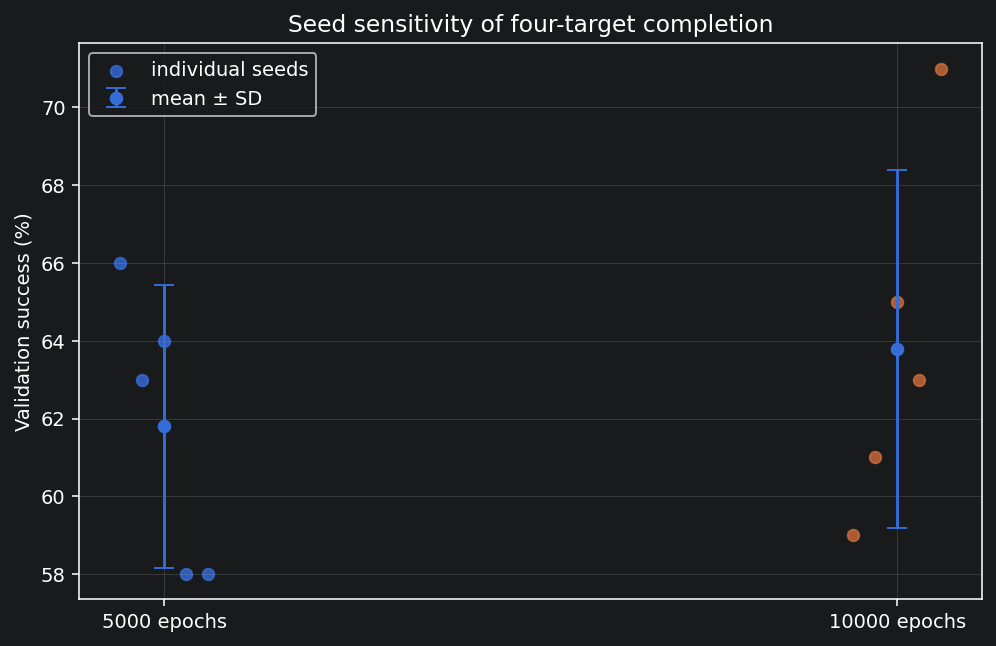

Saved: /home/matcho/projects/streaming-flow-policy/experiments/four_boxes_experiments/four_targets/runs/conditional_mlp_canonical_seed_sweep/seed_sensitivity_success.png


In [20]:
fig, ax = plt.subplots(
    figsize=(7, 4.5),
    dpi=140,
    constrained_layout=True,
)

x = np.arange(len(BUDGETS))

means = np.array([
    100 * aggregate[budget]["success"][0]
    for budget in BUDGETS
])
stds = np.array([
    100 * aggregate[budget]["success"][1]
    for budget in BUDGETS
])

ax.errorbar(
    x,
    means,
    yerr=stds,
    fmt="o",
    capsize=5,
    label="mean ± SD",
)

for i, budget in enumerate(BUDGETS):
    ys = [
        100
        * seed_results[(budget, seed)]["Validation"]["all_visited_rate"]
        for seed in SEEDS
    ]
    jitter = np.linspace(-0.06, 0.06, len(SEEDS))
    ax.scatter(
        np.full(len(SEEDS), x[i]) + jitter,
        ys,
        s=35,
        alpha=0.8,
        label="individual seeds" if i == 0 else None,
    )

ax.set_xticks(x)
ax.set_xticklabels([
    f"{budget} epochs"
    for budget in BUDGETS
])
ax.set_ylabel("Validation success (%)")
ax.set_title(
    "Seed sensitivity of four-target completion"
)
ax.grid(alpha=0.2)
ax.legend()

figure_path = SWEEP_ROOT / "seed_sensitivity_success.png"
fig.savefig(
    figure_path,
    dpi=180,
)
plt.show()

print("Saved:", figure_path)


Successful trajectories: 71/100
Failed trajectories: 29/100


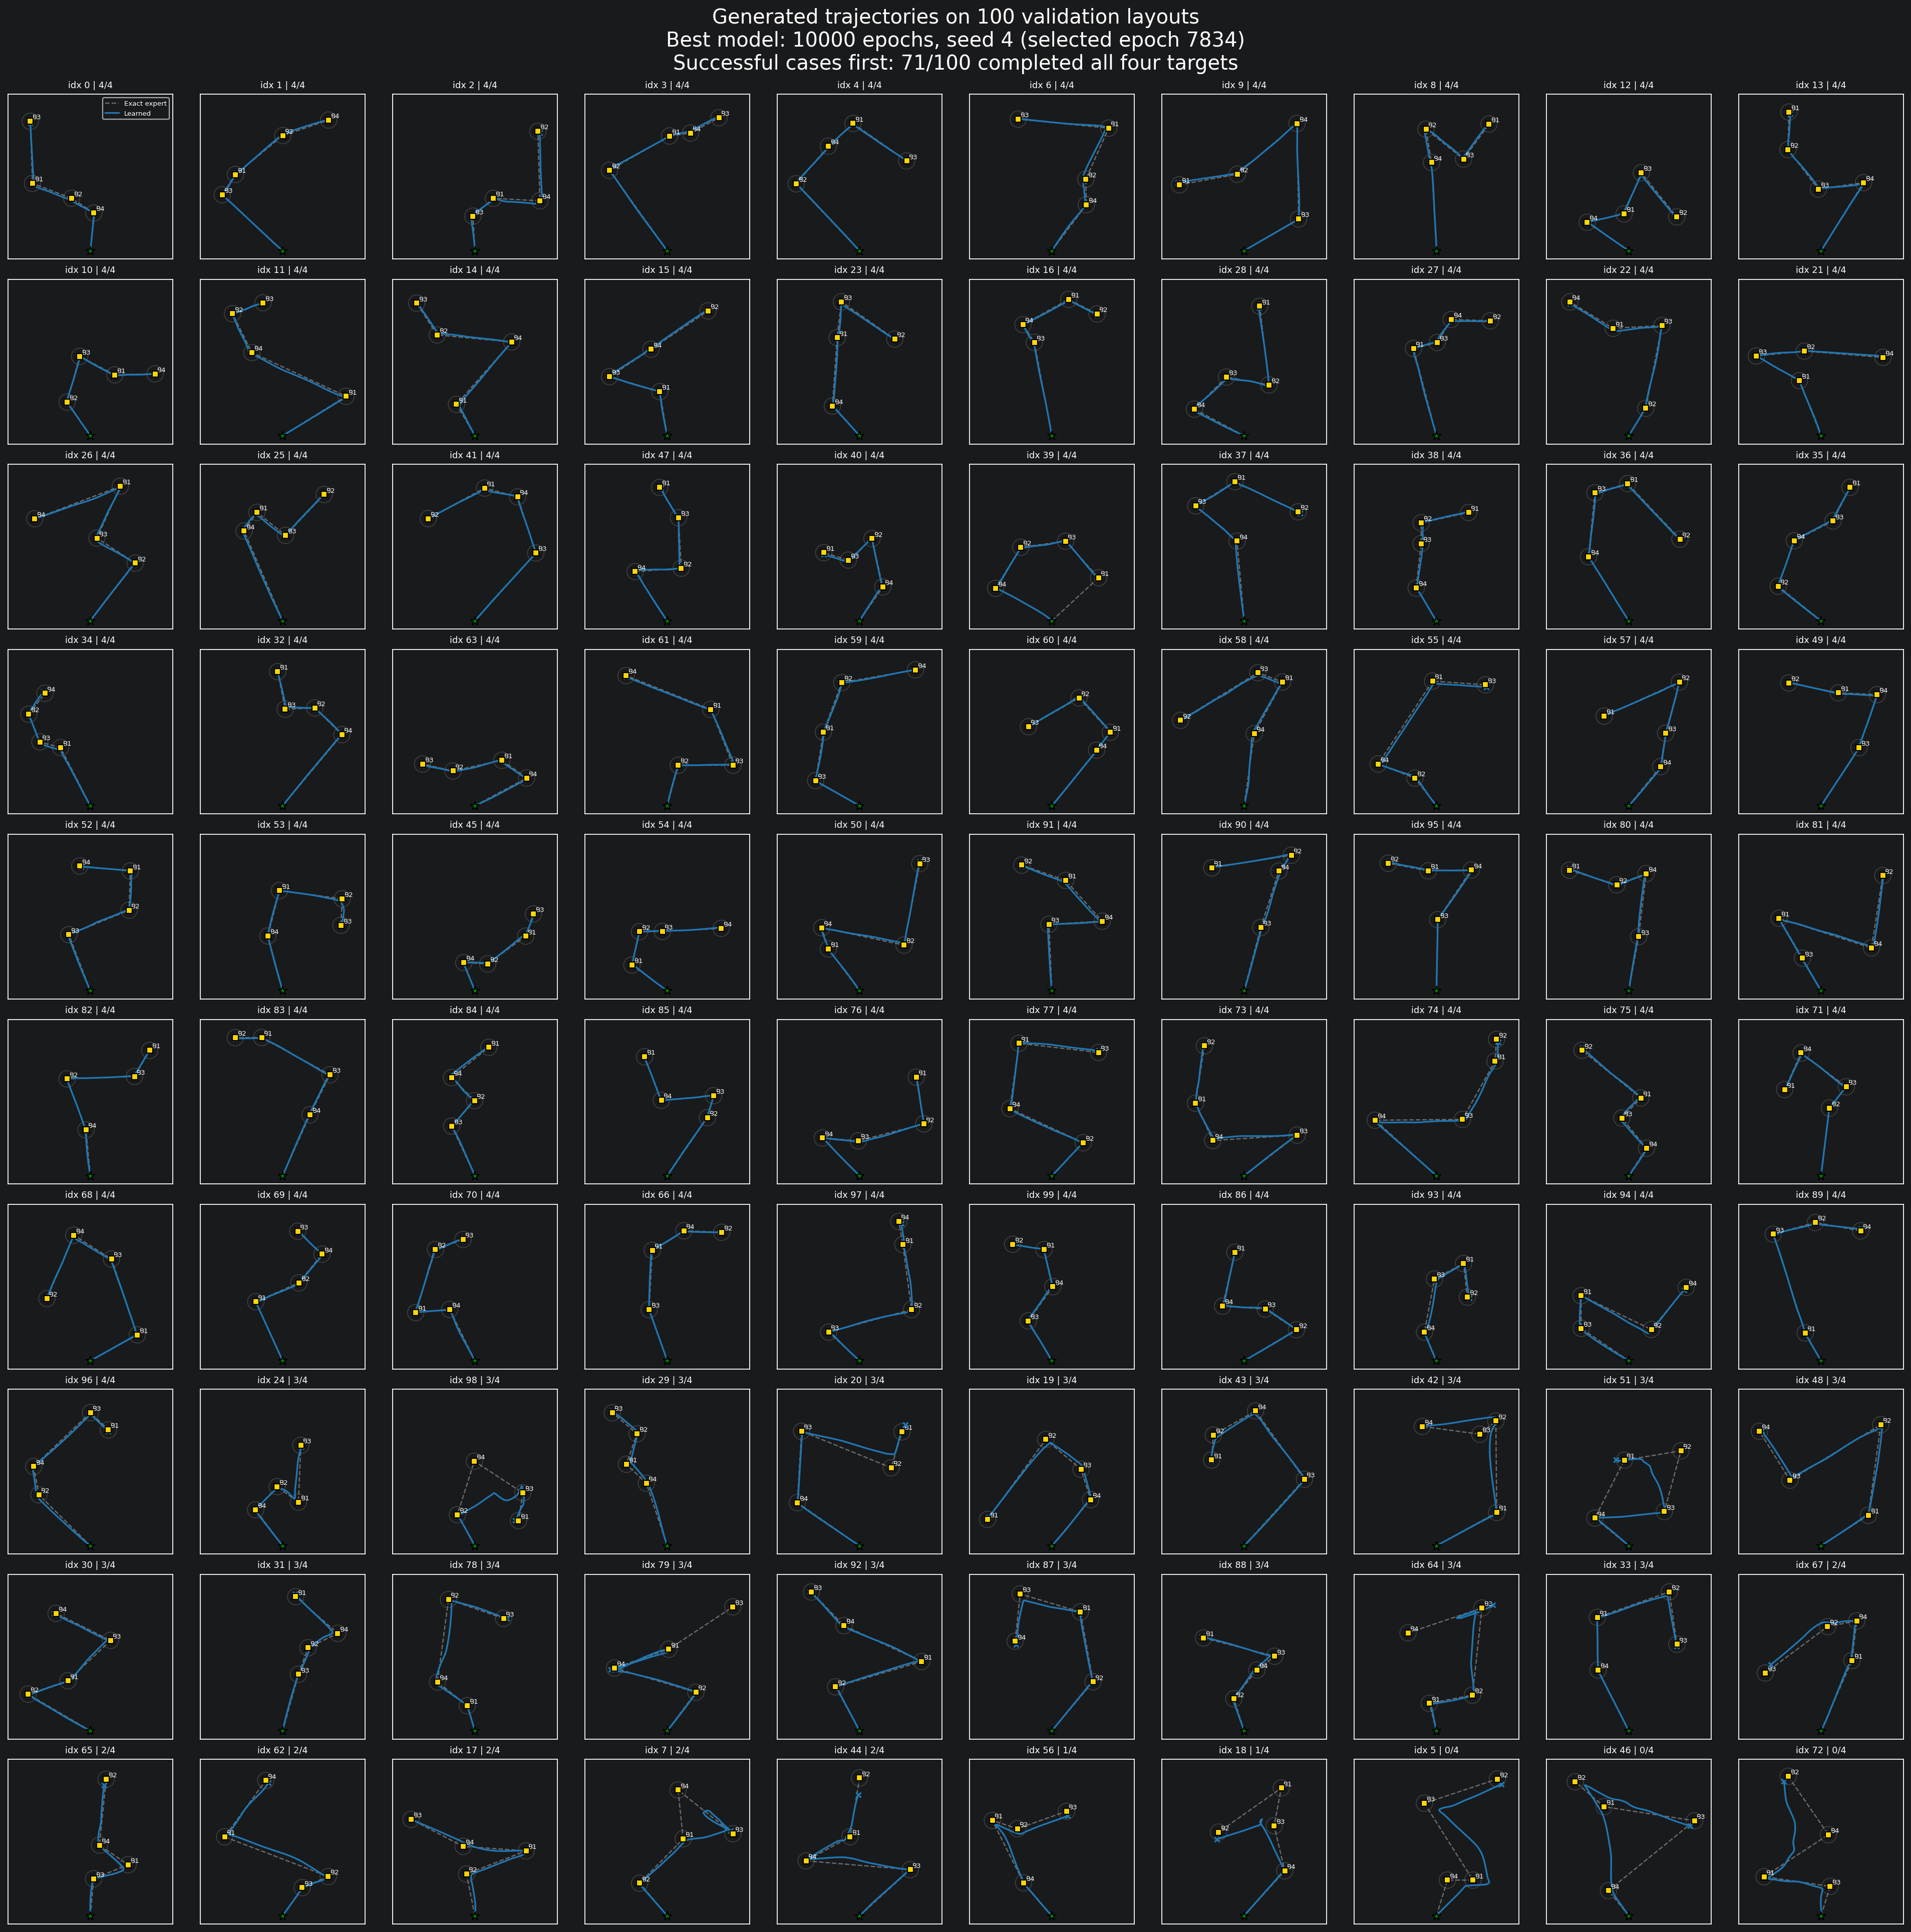


Saved figure to: /home/matcho/projects/streaming-flow-policy/experiments/four_boxes_experiments/four_targets/runs/conditional_mlp_canonical_seed_sweep/budget_10000_seed_4/validation_100_paths_grid_10x10_expert_comparison.png


In [25]:
# ============================================================
# Version 2:
# 100 trajectories in a 10x10 grid
# successful cases first, failures later
# learned rollout + exact expert path
# ============================================================

# ------------------------------------------------------------
# Sort layouts:
# successful (4/4) first, then failures by number visited
# ------------------------------------------------------------

sorted_order = np.argsort(
    -visit_counts
)

sorted_indices = indices[sorted_order]
sorted_starts = starts[sorted_order]
sorted_targets = targets_all[sorted_order]
sorted_paths = [
    rollout_paths[i]
    for i in sorted_order
]
sorted_visit_counts = visit_counts[sorted_order]

# Expert routes from the validation split
sorted_expert_routes = split["routes"][
    sorted_indices
]

num_success = int(
    np.sum(sorted_visit_counts == 4)
)

print(
    f"Successful trajectories: "
    f"{num_success}/{NUM_TO_PLOT}"
)

print(
    f"Failed trajectories: "
    f"{NUM_TO_PLOT - num_success}/{NUM_TO_PLOT}"
)


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    10,
    10,
    figsize=(24, 24),
    dpi=160,
    constrained_layout=True,
)

for plot_idx, ax in enumerate(axes.flat):

    start = sorted_starts[plot_idx]
    targets = sorted_targets[plot_idx]

    learned_path = sorted_paths[plot_idx]
    expert_route = sorted_expert_routes[plot_idx]

    count = sorted_visit_counts[plot_idx]
    original_index = sorted_indices[plot_idx]

    # --------------------------------------------------------
    # Exact expert shortest path
    # --------------------------------------------------------

    ax.plot(
        expert_route[:, 0],
        expert_route[:, 1],
        "--",
        color="gray",
        linewidth=1.1,
        alpha=0.8,
        label="Exact expert",
    )

    # --------------------------------------------------------
    # Learned rollout
    # --------------------------------------------------------

    ax.plot(
        learned_path[:, 0],
        learned_path[:, 1],
        color="tab:blue",
        linewidth=1.5,
        label="Learned",
    )

    # --------------------------------------------------------
    # Learned endpoint
    # --------------------------------------------------------

    ax.scatter(
        learned_path[-1, 0],
        learned_path[-1, 1],
        color="tab:blue",
        marker="x",
        s=20,
        zorder=4,
    )

    # --------------------------------------------------------
    # Targets
    # --------------------------------------------------------

    ax.scatter(
        targets[:, 0],
        targets[:, 1],
        marker="s",
        color="gold",
        edgecolor="black",
        s=34,
        zorder=5,
    )

    # --------------------------------------------------------
    # Start
    # --------------------------------------------------------

    ax.scatter(
        start[0],
        start[1],
        marker="*",
        s=65,
        color="green",
        edgecolor="black",
        zorder=6,
    )

    # --------------------------------------------------------
    # Visit tolerance circles + labels
    # --------------------------------------------------------

    for j, target in enumerate(targets):

        ax.add_patch(
            plt.Circle(
                target,
                VISIT_TOLERANCE,
                fill=False,
                color="gray",
                alpha=0.40,
                linewidth=0.7,
            )
        )

        ax.annotate(
            f"B{j+1}",
            target,
            xytext=(2, 2),
            textcoords="offset points",
            fontsize=6,
        )

    # --------------------------------------------------------
    # Title
    # --------------------------------------------------------

    ax.set_title(
        f"idx {original_index} | {count}/4",
        fontsize=8,
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_aspect(
        "equal",
        adjustable="box",
    )

    ax.grid(
        alpha=0.15
    )

    ax.set_xticks([])
    ax.set_yticks([])


# ============================================================
# Legend
# ============================================================

axes[0, 0].legend(
    fontsize=6,
    loc="upper right",
)


# ============================================================
# Overall title
# ============================================================

fig.suptitle(
    f"Generated trajectories on {NUM_TO_PLOT} "
    f"{SPLIT_NAME} layouts\n"
    f"Best model: {BEST_BUDGET} epochs, seed {BEST_SEED} "
    f"(selected epoch {checkpoint['epoch']})\n"
    f"Successful cases first: "
    f"{num_success}/{NUM_TO_PLOT} completed all four targets",
    fontsize=18,
)


# ============================================================
# Save
# ============================================================

save_path_v2 = (
    BEST_RUN_DIR
    / f"{SPLIT_NAME}_100_paths_grid_10x10_expert_comparison.png"
)

fig.savefig(
    save_path_v2,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print(
    "\nSaved figure to:",
    save_path_v2,
)